### Импорты и вспомогательные функции

In [1]:
import osmnx as ox
import networkx as nx
import numpy as np
import matplotlib.pyplot as plt
import random
import pickle

from tqdm import tqdm

In [17]:
tqdm._instances.clear()

In [18]:
def save_dict_to_pickle(data, filename):
    try:
        with open(filename, 'wb') as f:
            pickle.dump(data, f)
        print(f"Данные успешно сохранены в файл: {filename}")
    except Exception as e:
        print(f"Ошибка при сохранении: {e}")

In [19]:
def run_experiment_error(G, fractions, iterations):
    # Словарь со статистикой
    stats = {f: {'gcc': [], 'avg_s': [], 'top_d': [], 'len_d': [], 'ge': [], 'lcc': []} for f in fractions}

    # Сделаем граф простым
    G_simple = nx.Graph(G)
    total_nodes = len(G_simple)

    for f in fractions:
        print(f"Доля удаленных узлов: {f:.2f}")
        for i in tqdm(range(iterations)):
            G_temp = G_simple.copy()

            nodes_to_remove = random.sample(list(G_temp.nodes()), int(total_nodes * f))
            G_temp.remove_nodes_from(nodes_to_remove)

            components = sorted(nx.connected_components(G_temp), key=len, reverse=True)
            components_sizes = [len(c) for c in components]

            if components_sizes:
                # Размер GCC
                s_max_nodes = components[0]
                s_max_size = components_sizes[0]
                stats[f]['gcc'].append(s_max_size / total_nodes)

                # Средний путь
                if s_max_size > 1:
                    gcc_subgraph = G_temp.subgraph(s_max_nodes)
                    avg_top = nx.average_shortest_path_length(gcc_subgraph)
                    avg_len = nx.average_shortest_path_length(gcc_subgraph, weight='length')
                    stats[f]['top_d'].append(avg_top)
                    stats[f]['len_d'].append(avg_len)
                else:
                    stats[f]['top_d'].append(0)
                    stats[f]['len_d'].append(0)

                # Средний размер изолированных кластеров <s>
                finite_clusters = components_sizes[1:]
                if finite_clusters:
                    sum_sq = sum(s**2 for s in finite_clusters)
                    sum_val = sum(finite_clusters)
                    stats[f]['avg_s'].append(sum_sq / sum_val)
                else:
                    stats[f]['avg_s'].append(0)

                # Global Efficiency (GE)
                # Это покажет падение эффективности связи между всеми парами
                ge = nx.global_efficiency(G_temp)
                stats[f]['ge'].append(ge)

                # Локальный кластерный коэффициент (LCC)
                lcc = nx.average_clustering(G_temp)
                stats[f]['lcc'].append(lcc)

            else:
                stats[f]['gcc'].append(0)
                stats[f]['top_d'].append(0)
                stats[f]['len_d'].append(0)
                stats[f]['avg_s'].append(0)
                stats[f]['ge'].append(0)
                stats[f]['lcc'].append(0)
                
    return stats

In [20]:
def run_experiment_attack(G, fractions, iterations):
    # Словарь со статистикой
    stats = {f: {'gcc': [], 'avg_s': [], 'top_d': [], 'len_d': [], 'ge': [], 'lcc': []} for f in fractions}

    # Сделаем граф простым
    G_simple = nx.Graph(G)
    total_nodes = len(G_simple)

    nodes_sorted_by_degree = [node for node, degree in sorted(G_simple.degree(), key=lambda x: x[1], reverse=True)]

    for f in fractions:
        print(f"Доля удаленных узлов: {f:.2f}")
        for i in tqdm(range(iterations)):
            G_temp = G_simple.copy()

            n_to_remove = int(total_nodes * f)
            nodes_to_remove = nodes_sorted_by_degree[:n_to_remove]
            
            G_temp.remove_nodes_from(nodes_to_remove)

            components = sorted(nx.connected_components(G_temp), key=len, reverse=True)
            components_sizes = [len(c) for c in components]

            if components_sizes:
                # Размер GCC
                s_max_nodes = components[0]
                s_max_size = components_sizes[0]
                stats[f]['gcc'].append(s_max_size / total_nodes)

                # Средний путь
                if s_max_size > 1:
                    gcc_subgraph = G_temp.subgraph(s_max_nodes)
                    avg_top = nx.average_shortest_path_length(gcc_subgraph)
                    avg_len = nx.average_shortest_path_length(gcc_subgraph, weight='length')
                    stats[f]['top_d'].append(avg_top)
                    stats[f]['len_d'].append(avg_len)
                else:
                    stats[f]['top_d'].append(0)
                    stats[f]['len_d'].append(0)

                # Средний размер изолированных кластеров <s>
                finite_clusters = components_sizes[1:]
                if finite_clusters:
                    sum_sq = sum(s**2 for s in finite_clusters)
                    sum_val = sum(finite_clusters)
                    stats[f]['avg_s'].append(sum_sq / sum_val)
                else:
                    stats[f]['avg_s'].append(0)

                # Global Efficiency (GE)
                # Это покажет падение эффективности связи между всеми парами
                ge = nx.global_efficiency(G_temp)
                stats[f]['ge'].append(ge)

                # Локальный кластерный коэффициент (LCC)
                lcc = nx.average_clustering(G_temp)
                stats[f]['lcc'].append(lcc)

            else:
                stats[f]['gcc'].append(0)
                stats[f]['top_d'].append(0)
                stats[f]['len_d'].append(0)
                stats[f]['avg_s'].append(0)
                stats[f]['ge'].append(0)
                stats[f]['lcc'].append(0)
                
    return stats

In [21]:
def plot_metrics(stats, fractions):
    metrics = ['gcc', 'avg_s', 'top_d', 'len_d', 'ge', 'lcc']

    fig, ax = plt.subplots(1, 6, figsize=(22, 5))

    for i, key in enumerate(metrics):
        means = [np.mean(stats[f][key]) for f in fractions]
        
        ax[i].plot(fractions, means, label=key, color='teal')
        ax[i].set_title(key.upper())
        ax[i].set_xlabel('Fraction removed')
        ax[i].grid(True, alpha=0.3)
        ax[i].set_ylim(0, None)

    plt.tight_layout() 
    plt.show()

In [22]:
def set_seed(seed=42):
    np.random.seed(seed)
    random.seed(seed)

In [23]:
# Зададим кол-во шагов
steps = 51
# Зададим доли удаленных узлов
fractions = np.linspace(0, 1, steps)
# Зададим итерации для статистической значимости
iterations_error = 10
iterations_attack = 1

## Кольцевая структура (Москва)

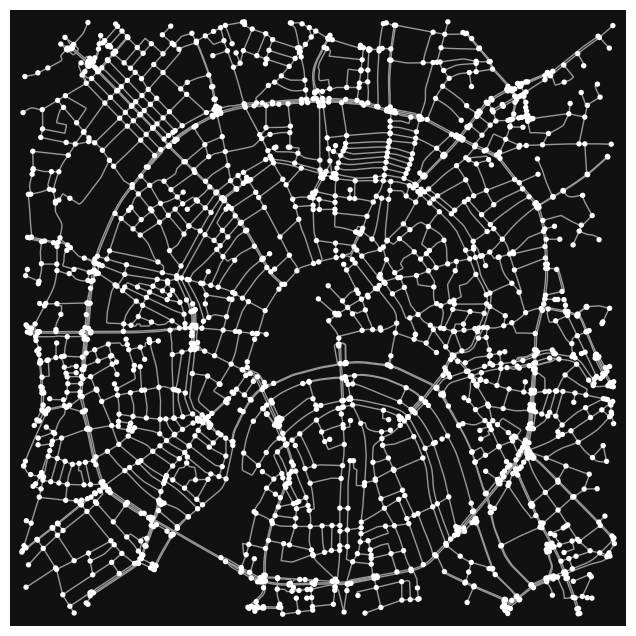

Кол-во узлов: 2066
Кол-во ребер: 3093


In [2]:
# Координаты центра Садового кольца
center_point = (55.7539, 37.6208)

# Скачиваем граф в радиусе 3000 метров (3 км)
G_moscow = ox.graph_from_point(center_point, dist=3000, network_type='drive')

G_un = G_moscow.to_undirected()
largest_component = max(nx.connected_components(G_un), key=len)
G_moscow = G_un.subgraph(largest_component).copy()

# Визуализация, чтобы проверить результат
ox.plot_graph(G_moscow)
print(f"Кол-во узлов: {len(G_moscow)}")
print(f"Кол-во ребер: {G_moscow.number_of_edges()}")

(<Figure size 800x800 with 1 Axes>, <Axes: >)

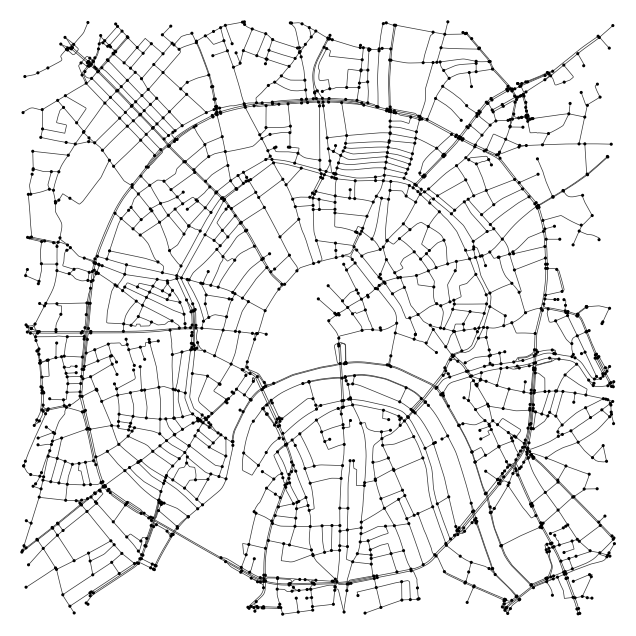

In [10]:
ox.plot_graph(
    G_moscow, 
    show=False, 
    save=True, 
    filepath='./Graphics/moscow_graph.png', 
    dpi=300,
    bgcolor='white',   
    node_color='black', 
    node_size=5,   
    edge_color='#333333', 
    edge_linewidth=0.5 
)

### Ошибки

In [41]:
# Установим сид для возпроизводимости
set_seed(42)
# Симулируем ошибки
Moscow_error = run_experiment_error(G_moscow, fractions, iterations_error)

Доля удаленных узлов: 0.00


100%|██████████| 10/10 [05:26<00:00, 32.67s/it]


Доля удаленных узлов: 0.02


100%|██████████| 10/10 [05:10<00:00, 31.02s/it]


Доля удаленных узлов: 0.04


...

100%|██████████| 10/10 [00:00<00:00, 60.72it/s]


Доля удаленных узлов: 0.98


100%|██████████| 10/10 [00:00<00:00, 94.34it/s]


Доля удаленных узлов: 1.00


100%|██████████| 10/10 [00:00<00:00, 99.93it/s]


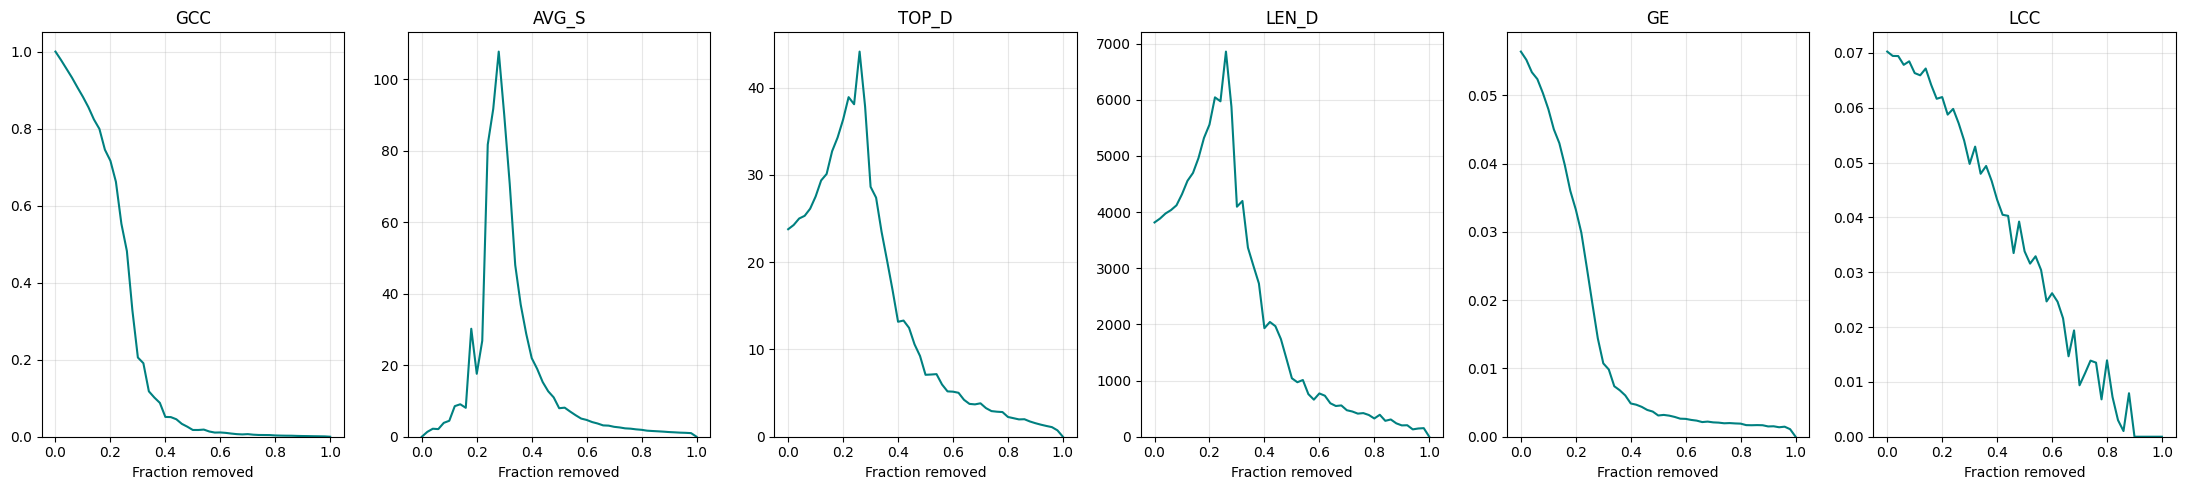

In [ ]:
# Визуализируем
plot_metrics(Moscow_error, fractions)

In [50]:
# Сохраним результат
save_dict_to_pickle(Moscow_error, "Moscow_error.pkl")

Данные успешно сохранены в файл: Moscow_error.pkl


### Атаки

In [9]:
# Симулируем атаки
Moscow_attack = run_experiment_attack(G_moscow, fractions, iterations_attack)

Доля удаленных узлов: 0.00


100%|██████████| 1/1 [00:39<00:00, 39.71s/it]


Доля удаленных узлов: 0.02


100%|██████████| 1/1 [00:37<00:00, 37.86s/it]


Доля удаленных узлов: 0.04


...

100%|██████████| 1/1 [00:00<00:00, 71.43it/s]


Доля удаленных узлов: 0.98


100%|██████████| 1/1 [00:00<00:00, 66.74it/s]


Доля удаленных узлов: 1.00


100%|██████████| 1/1 [00:00<00:00, 77.26it/s]


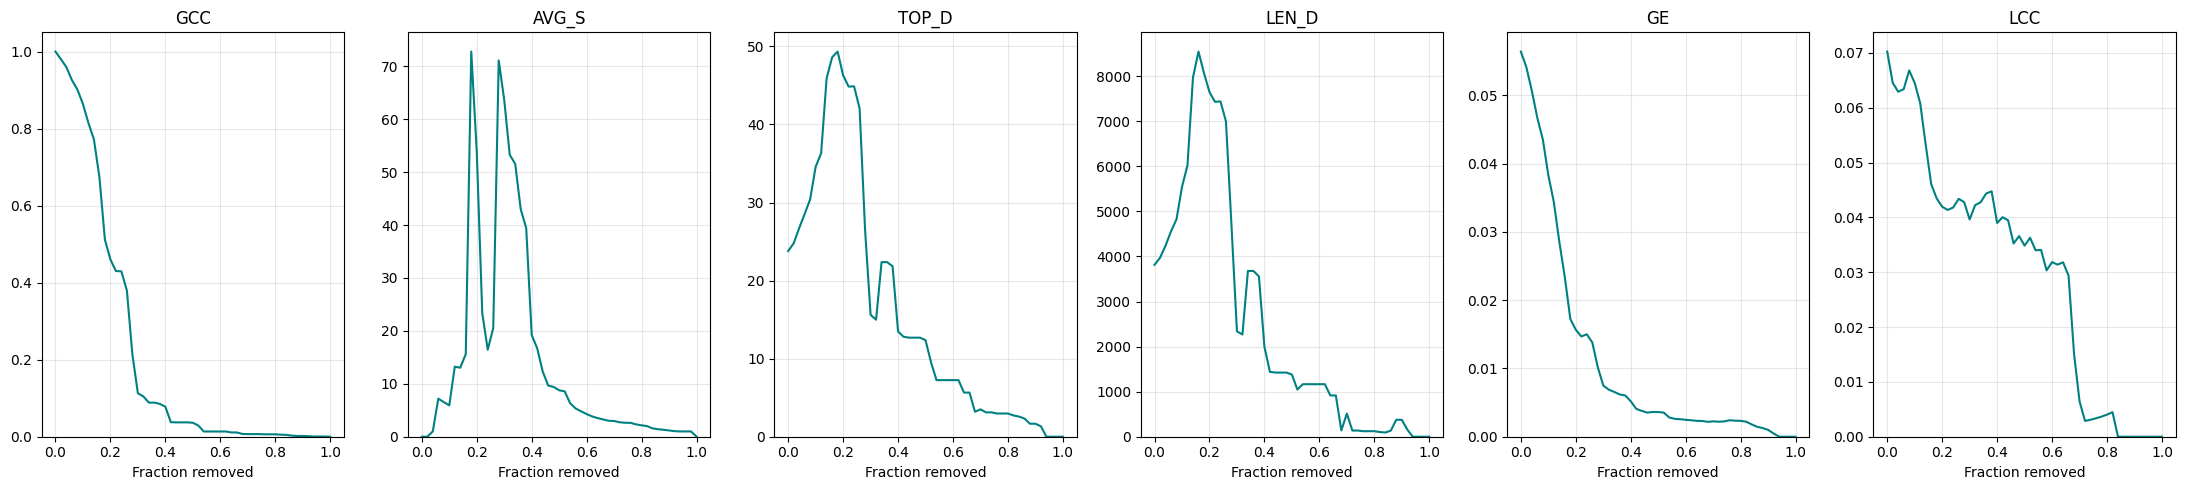

In [10]:
plot_metrics(Moscow_attack, fractions)

In [11]:
save_dict_to_pickle(Moscow_attack, "Moscow_attack.pkl")

Данные успешно сохранены в файл: Moscow_attack.pkl


## Сетчатая структура (Нью-Йорк)

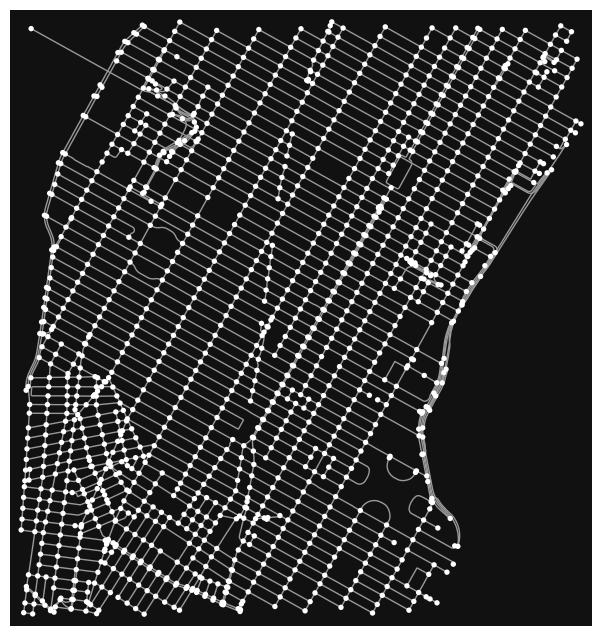

Кол-во узлов: 1307
Кол-во ребер: 2338


In [30]:
north = 40.7634
south = 40.7234
east = -73.9607
west = -74.0107

# Скачиваем граф строго в границах квадрата
G_nyc = ox.graph_from_bbox((west, south, east, north), network_type='drive')

while True:
    nodes_to_remove = [n for n, d in G_nyc.degree() if d <= 1]
    if not nodes_to_remove:
        break
    G_nyc.remove_nodes_from(nodes_to_remove)

# Переводим в неориентированный вид и выделяем GCC
G_un_ny = G_nyc.to_undirected()
largest_component_ny = max(nx.connected_components(G_un_ny), key=len)

# Создаем финальный граф
G_nyc = G_un_ny.subgraph(largest_component_ny).copy()

# Визуализация для проверки "сетчатости"
ox.plot_graph(G_nyc)
print(f"Кол-во узлов: {len(G_nyc)}")
print(f"Кол-во ребер: {G_nyc.number_of_edges()}")

(<Figure size 800x800 with 1 Axes>, <Axes: >)

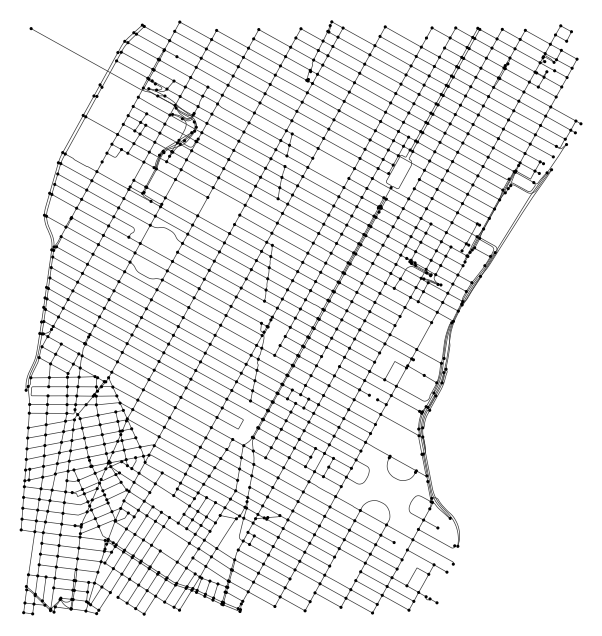

In [15]:
ox.plot_graph(
    G_nyc, 
    show=False, 
    save=True, 
    filepath='./Graphics/new_york_graph.png', 
    dpi=300,
    bgcolor='white',   
    node_color='black', 
    node_size=5,   
    edge_color='#333333', 
    edge_linewidth=0.5 
)

### Ошибки

In [24]:
# Установим сид для возпроизводимости
set_seed(42)
# Симулируем ошибки
New_York_error = run_experiment_error(G_nyc, fractions, iterations_error)

Доля удаленных узлов: 0.00


100%|██████████| 10/10 [03:20<00:00, 20.02s/it]


Доля удаленных узлов: 0.02


100%|██████████| 10/10 [02:30<00:00, 15.07s/it]


Доля удаленных узлов: 0.04


...

100%|██████████| 10/10 [00:00<00:00, 126.60it/s]


Доля удаленных узлов: 0.98


100%|██████████| 10/10 [00:00<00:00, 127.64it/s]


Доля удаленных узлов: 1.00


100%|██████████| 10/10 [00:00<00:00, 107.18it/s]


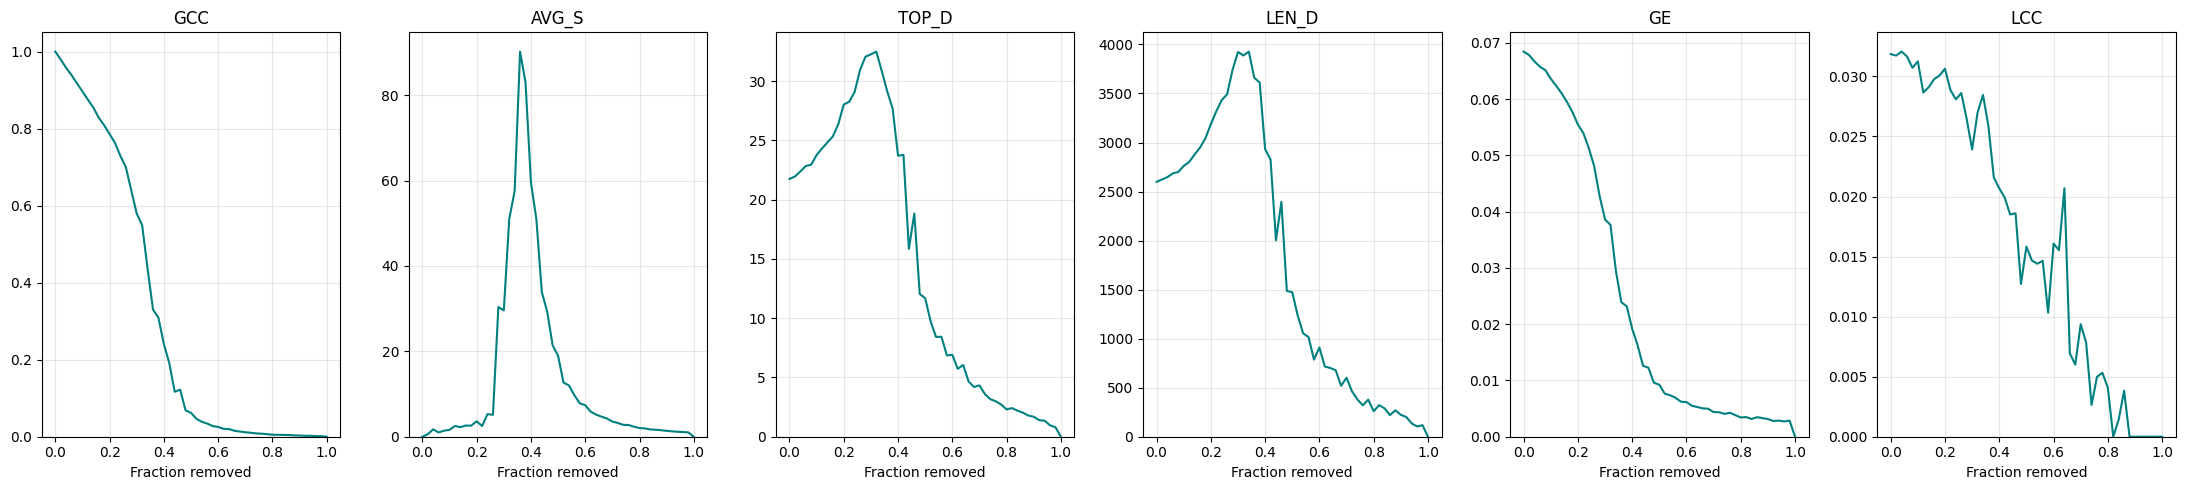

In [25]:
plot_metrics(New_York_error, fractions)

In [29]:
save_dict_to_pickle(New_York_error, "New_York_error.pkl")

Данные успешно сохранены в файл: New_York_error.pkl


### Атаки

In [26]:
New_York_attack = run_experiment_attack(G_nyc, fractions, iterations_attack)

Доля удаленных узлов: 0.00


100%|██████████| 1/1 [00:15<00:00, 15.46s/it]


Доля удаленных узлов: 0.02


100%|██████████| 1/1 [00:15<00:00, 15.05s/it]


Доля удаленных узлов: 0.04


...

100%|██████████| 1/1 [00:00<00:00, 60.32it/s]


Доля удаленных узлов: 0.98


100%|██████████| 1/1 [00:00<00:00, 66.07it/s]


Доля удаленных узлов: 1.00


100%|██████████| 1/1 [00:00<00:00, 107.14it/s]


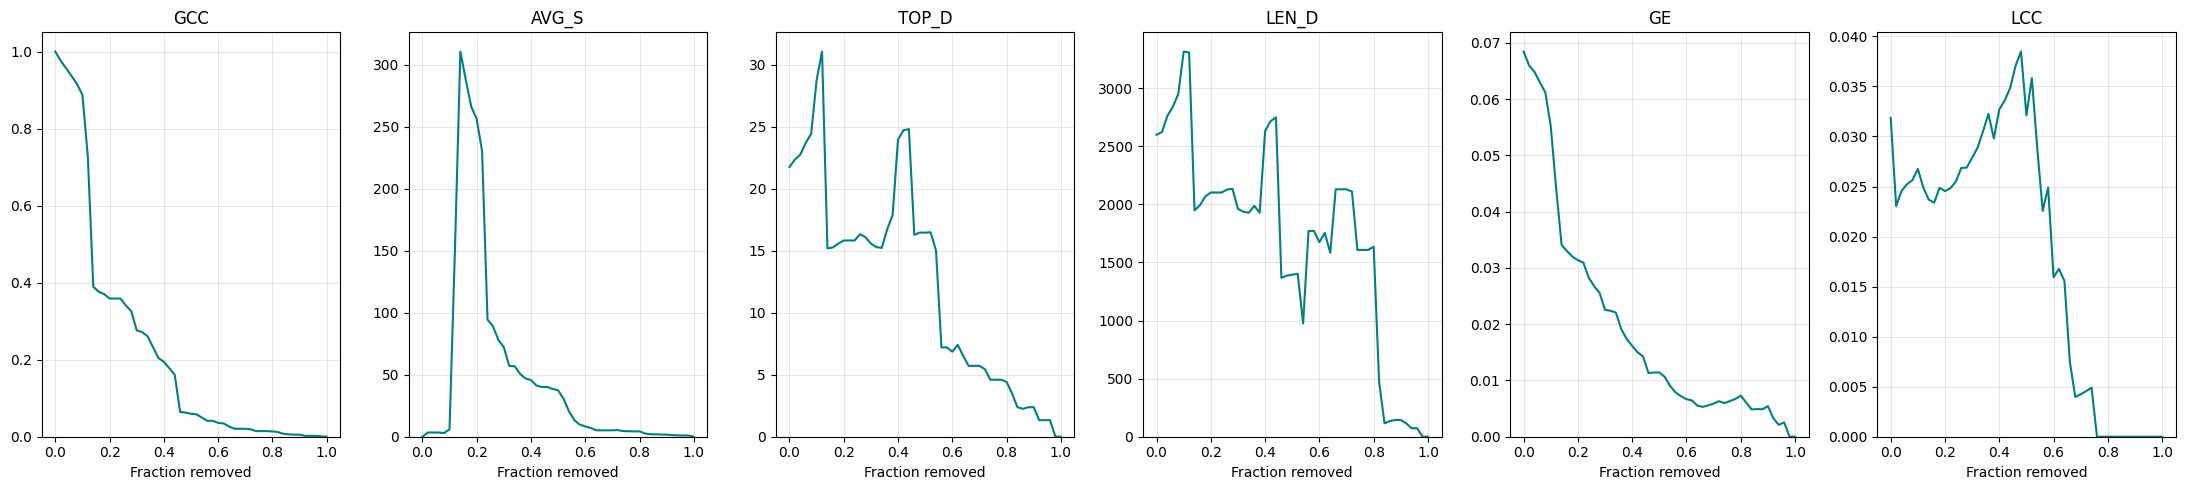

In [27]:
plot_metrics(New_York_attack, fractions)

In [28]:
save_dict_to_pickle(New_York_attack, "New_York_attack.pkl")

Данные успешно сохранены в файл: New_York_attack.pkl


## Линейная структура (Волгоград)

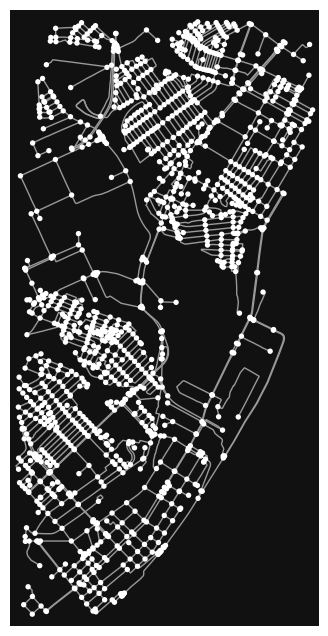

Кол-во узлов: 1310
Кол-во ребер: 1907


In [5]:
# Пример получения линейного участка Волгограда
north, south = 48.78, 48.70 
east, west = 44.56, 44.50
G_volgograd = ox.graph_from_bbox((west, south, east, north), network_type='drive')

G_un_vol = G_volgograd.to_undirected()
largest_component_vol = max(nx.connected_components(G_un_vol), key=len)

G_volgograd = G_un_vol.subgraph(largest_component_vol).copy()

# Визуализация
ox.plot_graph(G_volgograd)
print(f"Кол-во узлов: {len(G_volgograd)}")
print(f"Кол-во ребер: {G_volgograd.number_of_edges()}")

(<Figure size 800x800 with 1 Axes>, <Axes: >)

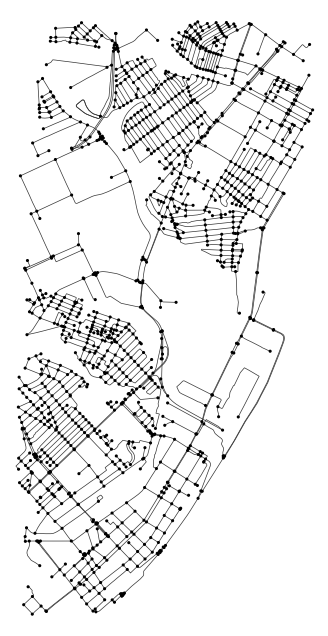

In [12]:
ox.plot_graph(
    G_volgograd, 
    show=False, 
    save=True, 
    filepath='./Graphics/volgograd_graph.png', 
    dpi=300,
    bgcolor='white',   
    node_color='black', 
    node_size=5,   
    edge_color='#333333', 
    edge_linewidth=0.5 
)

### Ошибки

In [87]:
# Установим сид для возпроизводимости
set_seed(42)
# Симулируем ошибки
Volgograd_error = run_experiment_error(G_volgograd, fractions, iterations_error)

Доля удаленных узлов: 0.00


100%|██████████| 10/10 [02:38<00:00, 15.89s/it]


Доля удаленных узлов: 0.02


100%|██████████| 10/10 [02:27<00:00, 14.78s/it]


Доля удаленных узлов: 0.04


...

100%|██████████| 10/10 [00:00<00:00, 99.95it/s]


Доля удаленных узлов: 0.98


100%|██████████| 10/10 [00:00<00:00, 73.58it/s]


Доля удаленных узлов: 1.00


100%|██████████| 10/10 [00:00<00:00, 130.60it/s]


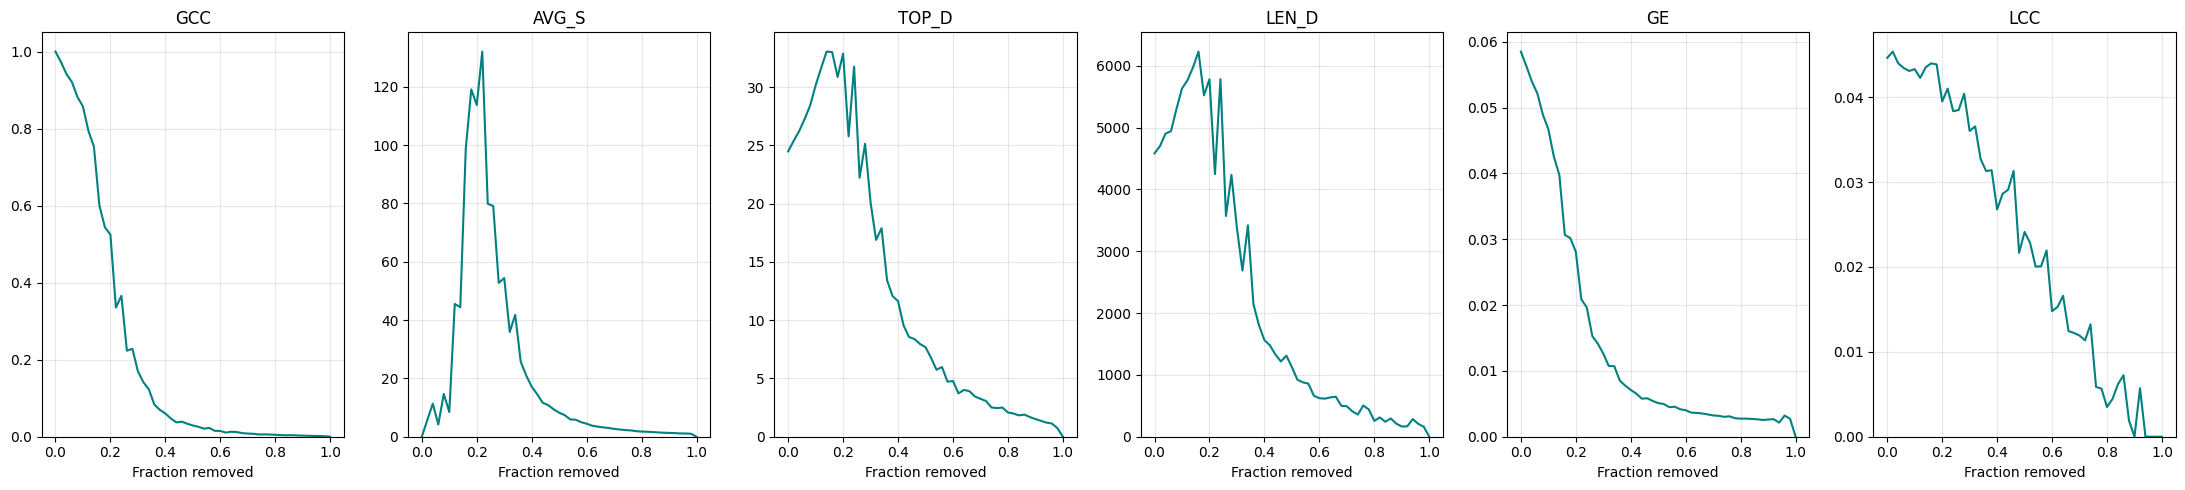

In [88]:
plot_metrics(Volgograd_error, fractions)

In [89]:
save_dict_to_pickle(Volgograd_error, "Volgograd_error.pkl")

Данные успешно сохранены в файл: Volgograd_error.pkl


### Атаки

In [91]:
Volgograd_attack = run_experiment_attack(G_volgograd, fractions, iterations_attack)

Доля удаленных узлов: 0.00


100%|██████████| 1/1 [00:14<00:00, 14.82s/it]


Доля удаленных узлов: 0.02


100%|██████████| 1/1 [00:13<00:00, 13.39s/it]


Доля удаленных узлов: 0.04


...

100%|██████████| 1/1 [00:00<00:00, 48.82it/s]


Доля удаленных узлов: 0.98


100%|██████████| 1/1 [00:00<00:00, 40.17it/s]


Доля удаленных узлов: 1.00


100%|██████████| 1/1 [00:00<00:00, 59.00it/s]


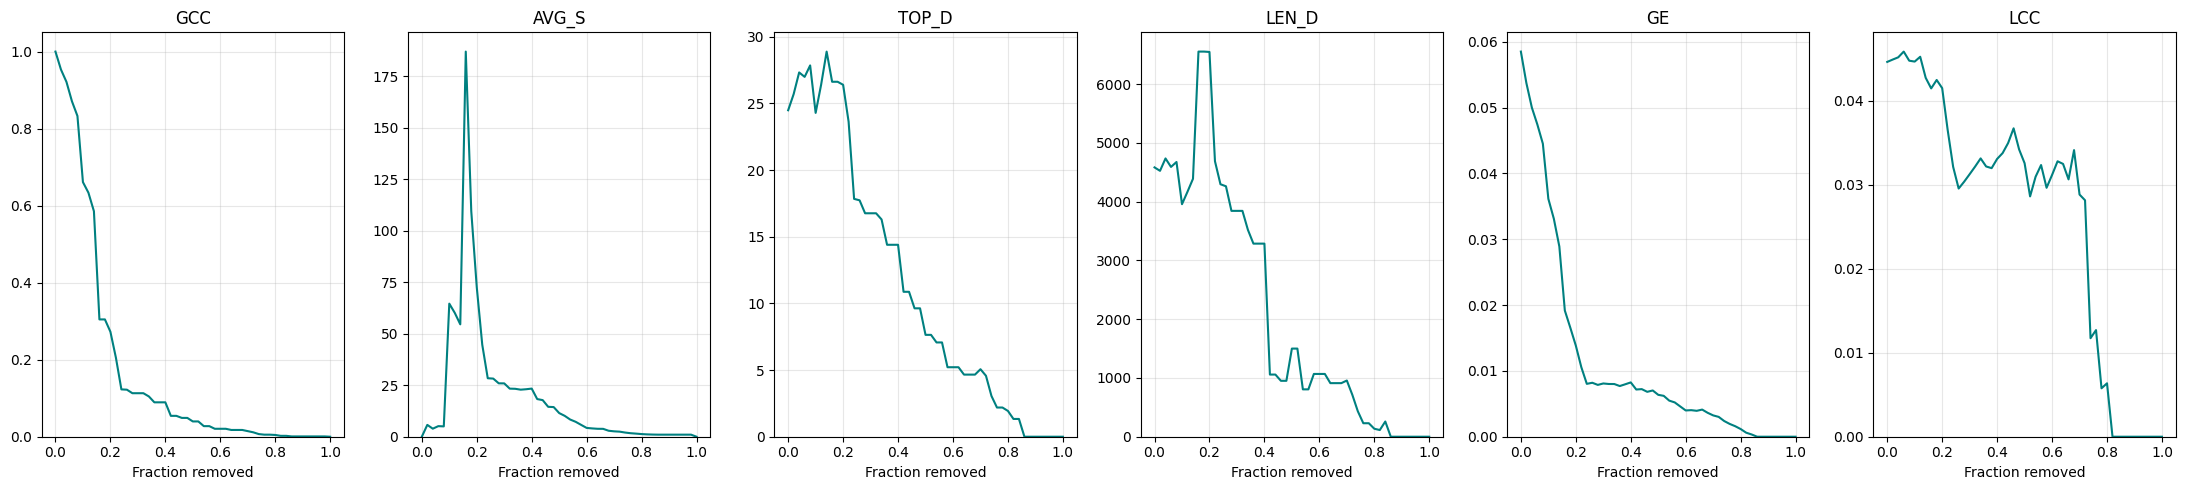

In [92]:
plot_metrics(Volgograd_attack, fractions)

In [93]:
save_dict_to_pickle(Volgograd_attack, "Volgograd_attack.pkl")

Данные успешно сохранены в файл: Volgograd_attack.pkl


## Хаотичная структура (Лондон)

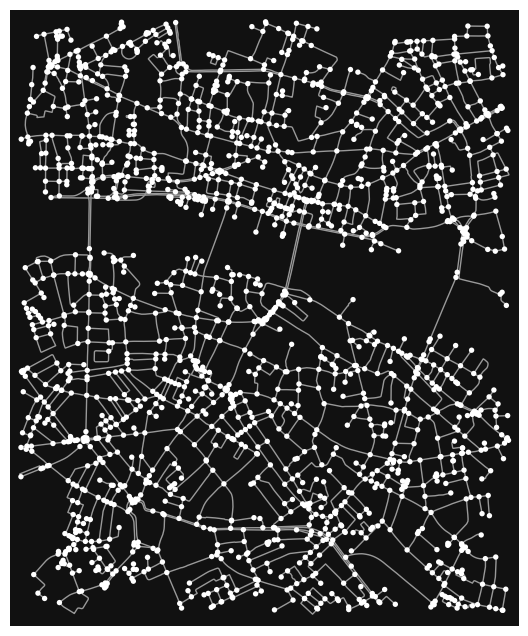

Кол-во узлов: 1806
Кол-во ребер: 2360


In [6]:
# Исторический центр Лондона (примерно 28 км2)
# Порядок для старой версии: (west, south, east, north)
west, south, east, north = -0.11, 51.49, -0.07, 51.52

G_london = ox.graph_from_bbox((west, south, east, north), network_type='drive')

G_un_lon = G_london.to_undirected()
largest_component_lon = max(nx.connected_components(G_un_lon), key=len)

# Создаем финальный граф G_final (перезаписываем переменную для вашего основного кода)
G_london = G_un_lon.subgraph(largest_component_lon).copy()

# Визуализация 
ox.plot_graph(G_london)
print(f"Кол-во узлов: {len(G_london)}")
print(f"Кол-во ребер: {G_london.number_of_edges()}")

(<Figure size 800x800 with 1 Axes>, <Axes: >)

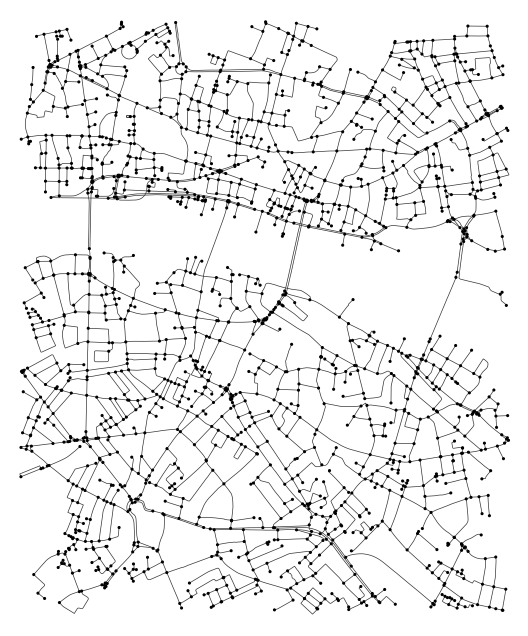

In [13]:
ox.plot_graph(
    G_london, 
    show=False, 
    save=True, 
    filepath='./Graphics/london_graph.png', 
    dpi=300,
    bgcolor='white',   
    node_color='black', 
    node_size=5,   
    edge_color='#333333', 
    edge_linewidth=0.5 
)

### Ошибки

In [96]:
# Установим сид для возпроизводимости
set_seed(42)
# Симулируем ошибки
London_error = run_experiment_error(G_london, fractions, iterations_error)

Доля удаленных узлов: 0.00


100%|██████████| 10/10 [07:56<00:00, 47.66s/it]


Доля удаленных узлов: 0.02


100%|██████████| 10/10 [06:00<00:00, 36.03s/it]


Доля удаленных узлов: 0.04


...

100%|██████████| 10/10 [00:00<00:00, 91.65it/s]


Доля удаленных узлов: 0.98


100%|██████████| 10/10 [00:00<00:00, 84.58it/s]


Доля удаленных узлов: 1.00


100%|██████████| 10/10 [00:00<00:00, 60.87it/s]


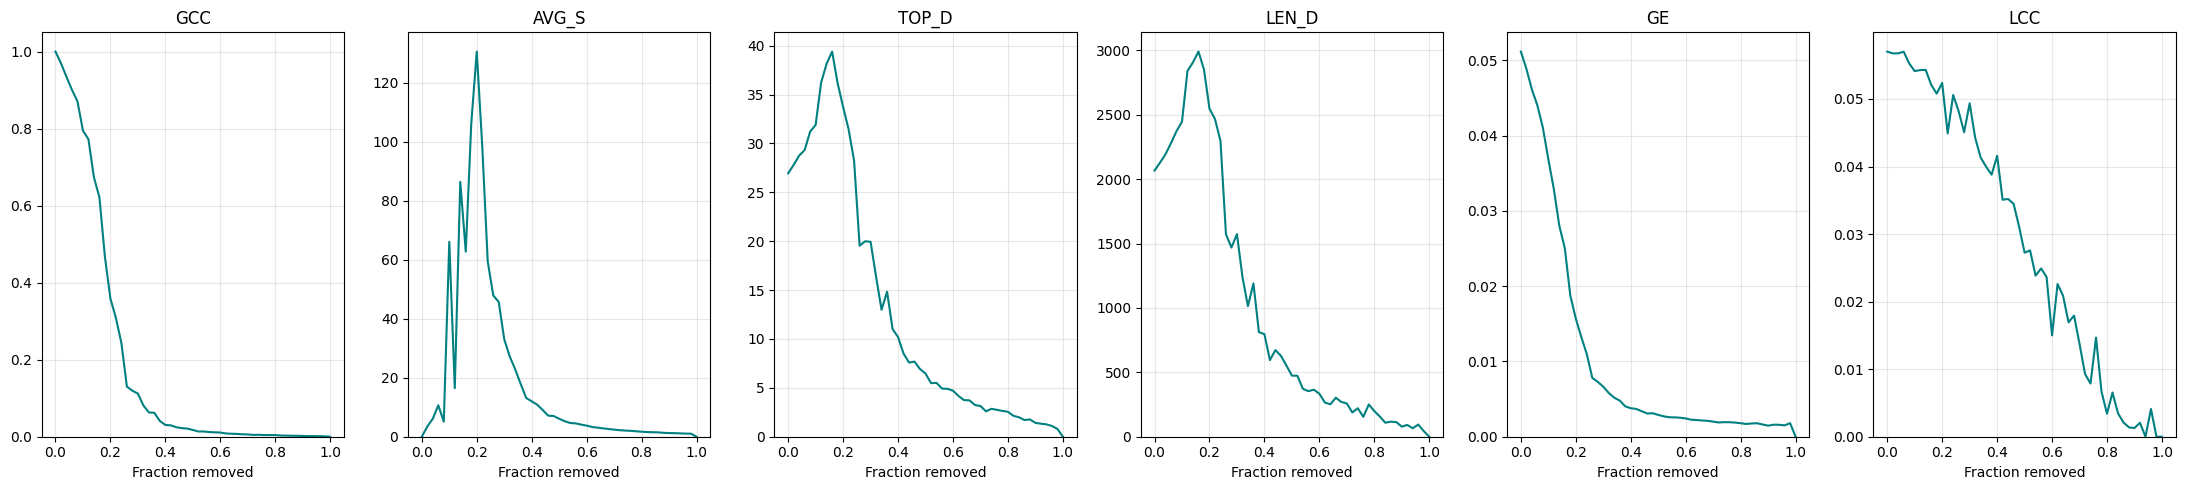

In [97]:
plot_metrics(London_error, fractions)

In [98]:
save_dict_to_pickle(London_error, "London_error.pkl")

Данные успешно сохранены в файл: London_error.pkl


### Атаки

In [99]:
London_attack = run_experiment_attack(G_london, fractions, iterations_attack)

Доля удаленных узлов: 0.00


100%|██████████| 1/1 [00:26<00:00, 26.34s/it]


Доля удаленных узлов: 0.02


100%|██████████| 1/1 [00:26<00:00, 26.18s/it]


Доля удаленных узлов: 0.04


...

100%|██████████| 1/1 [00:00<00:00, 72.97it/s]


Доля удаленных узлов: 0.98


100%|██████████| 1/1 [00:00<00:00, 80.86it/s]


Доля удаленных узлов: 1.00


100%|██████████| 1/1 [00:00<00:00, 87.17it/s]


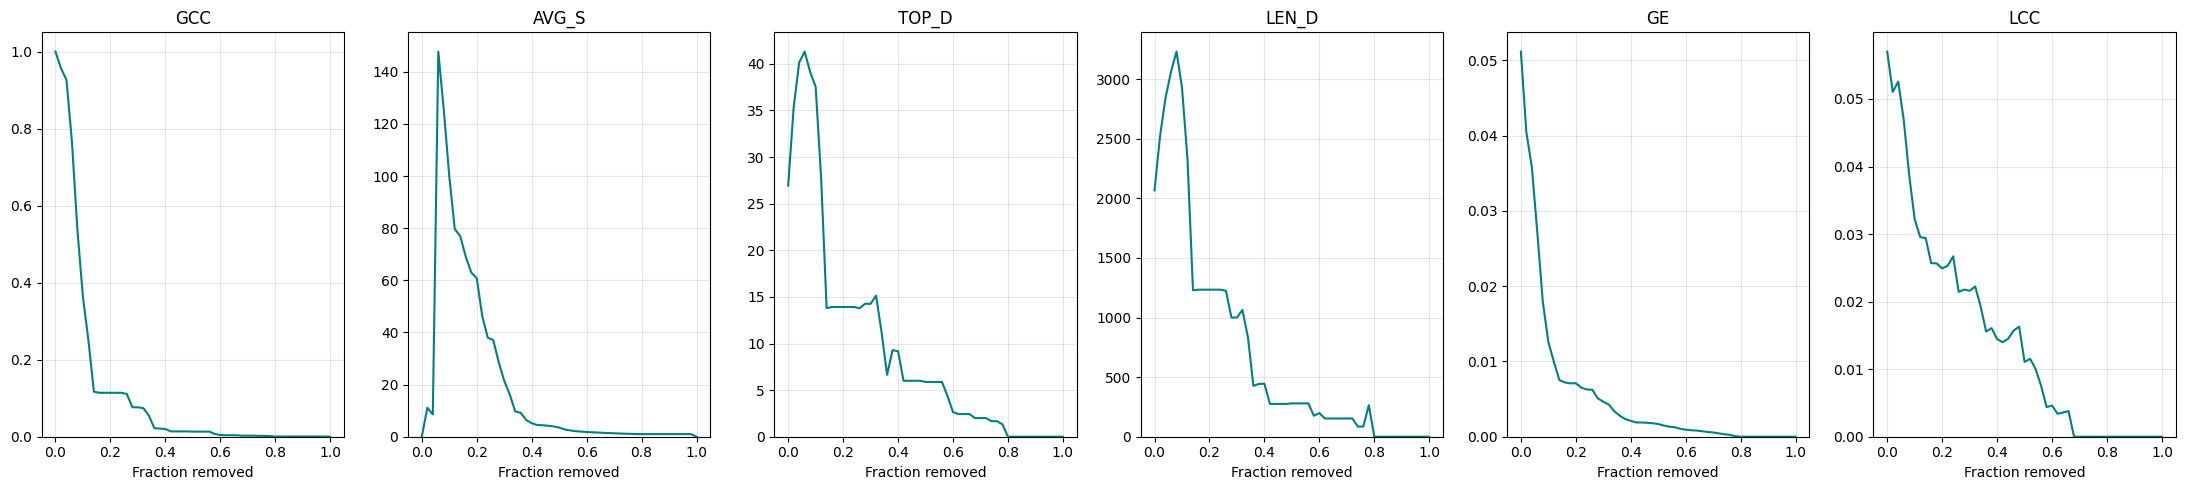

In [100]:
plot_metrics(London_attack, fractions)

In [101]:
save_dict_to_pickle(London_attack, "London_attack.pkl")

Данные успешно сохранены в файл: London_attack.pkl
